In [20]:
import config
import yfinance as yf
import pandas as pd, numpy as np
import ta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")

TICKER = "BTC-USD"
PERIOD = "3y"
TRAIN_SPLIT_RATIO = 0.8

In [21]:
Ticker = yf.Ticker(ticker=f'{TICKER}')
df = Ticker.history(PERIOD)
start = df.index.min()
end = df.index.max()
sample_size = len(df)

df["SMA9"] = df["Close"].rolling(window=9).mean()
df["SMA25"] = df["Close"].rolling(window=25).mean()
df["Close_SMA9_ratio"] = (df["Close"] - df["SMA9"]) / df["SMA9"]
df["Close_SMA25_ratio"] = (df["Close"] - df["SMA25"]) / df["SMA25"]
df["Close_High"] = df["Close"] / df["High"]
df["Close_Low"] = df["Close"] / df["Low"]
rsi = ta.momentum.RSIIndicator(close=df["Close"])
df["RSI"] = rsi.rsi()
df["Overbought"] = (df["RSI"] > 70).astype(int)
df["Oversold"] = (df["RSI"] < 30).astype(int)
macd = ta.trend.MACD(close=df["Close"])
df["MACD"] = macd.macd()
df["Signal_Line"] = macd.macd_signal()
df["MACD_Diff"] = ta.trend.macd_diff(df["Close"])
df["MACD_bullish"] = (df["MACD"] > 0).astype(int)
df["Bullish_Crossover"] = (df["MACD"] > df["Signal_Line"]).astype(int)

threshold = 0.03
df['Return_5d'] = df['Close'].pct_change(5)
df['Return_5d_later'] = df['Return_5d'].shift(-5)
df['Target'] = 0
df.loc[df['Return_5d_later']>threshold, 'Target'] = 1 # buy
df.loc[df['Return_5d_later']<-threshold, 'Target'] = 2 # sell
df.dropna(inplace=True)

df['Target'].value_counts(normalize=True)

Target
0    0.512748
1    0.273843
2    0.213409
Name: proportion, dtype: float64

In [22]:
FEATURES = ["Volume","SMA9","Close_High","Overbought","Oversold","MACD_bullish","Bullish_Crossover","Signal_Line"]
Target = 'Target'
TARGET_LABELS = {0:'Hold', 1:'Buy', 2:'Sell'}

In [23]:
train_samples = int(df.shape[0] * TRAIN_SPLIT_RATIO)
train_data = df.iloc[:train_samples]
test_data = df.iloc[train_samples:]
X_train, y_train = train_data[FEATURES], train_data["Target"]
X_test, y_test = test_data[FEATURES], test_data["Target"]
test_samples = len(df) - train_samples
print(f"✅ Data split done. Train: {train_samples}, Test: {test_samples}")

✅ Data split done. Train: 847, Test: 212


In [24]:
SPLITS = 5
tscv = TimeSeriesSplit(n_splits=SPLITS)
metrics = []
for train_idx, valid_idx in tscv.split(X_train, y_train):
    x_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    x_va, y_va = X_train.iloc[valid_idx], y_train.iloc[valid_idx]

    model, _ = config.train_base_model(x_tr, y_tr, x_va, y_va, model_name="XGB")
    y_pred = model.predict(x_va)
    results = config.evaluate_model(y_va, y_pred, "XGB")
    metrics.append(results)
print("Cross Validation Results:\n", pd.DataFrame(metrics).to_string(max_colwidth=50))

Cross Validation Results:
   model  precision    recall        f1                           confusion_matrix
0   XGB   0.418879  0.390071  0.278714       [[54, 1, 9], [51, 1, 9], [16, 0, 0]]
1   XGB   0.093003  0.304965  0.142538       [[0, 58, 0], [0, 43, 0], [0, 40, 0]]
2   XGB   0.373651  0.354610  0.359935  [[27, 14, 16], [19, 16, 19], [13, 10, 7]]
3   XGB   0.308477  0.439716  0.360826     [[55, 16, 0], [27, 7, 0], [25, 11, 0]]
4   XGB   0.526623  0.524823  0.504307      [[68, 4, 20], [18, 3, 7], [18, 0, 3]]


In [25]:
final_model, _ = config.train_base_model(X_train, y_train,X_valid=None, y_valid=None , model_name="XGB", iters=100)

In [27]:
test_pred = final_model.predict(X_test)

In [28]:
pd.Series(test_pred).value_counts(normalize=True).sort_index()

0    0.688679
1    0.136792
2    0.174528
Name: proportion, dtype: float64

In [29]:
merged_df = test_data[['Close','Return_5d','Return_5d_later','Target']]
merged_df['pred'] = test_pred

In [30]:
signal_map = {0:0, 1:1, 2:-1}
merged_df['signal_actual'] = merged_df['Target'].map(signal_map)
merged_df['signal_pred'] = merged_df['pred'].map(signal_map)

In [31]:
merged_df['market'] = merged_df['signal_actual'].cumsum()
merged_df['strategy'] = merged_df['signal_pred'].cumsum()

In [32]:
merged_df['signal_pred_shifted'] = merged_df['signal_pred'].shift(1)  # avoid lookahead in execution
merged_df['strategy_returns'] = merged_df['signal_pred_shifted'] * merged_df['Return_5d']
merged_df['cumulative_strategy'] = merged_df['strategy_returns'].cumsum()

In [33]:
merged_df['signal_actual_shifted'] = merged_df['signal_actual'].shift(1)  # avoid lookahead in execution
merged_df['market_returns'] = merged_df['signal_actual_shifted'] * merged_df['Return_5d']
merged_df['cumulative_market'] = merged_df['market_returns'].cumsum()

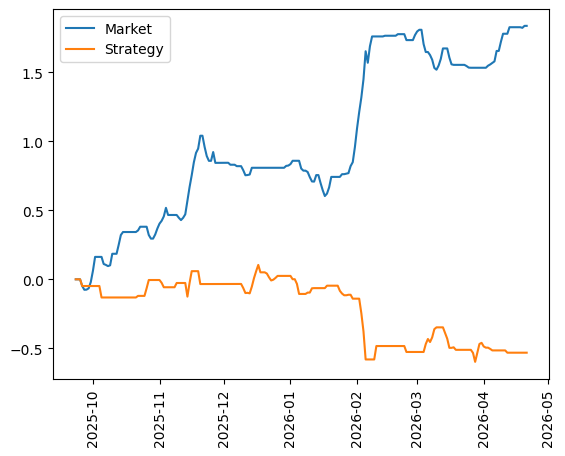

In [34]:
plt.plot(merged_df.index, merged_df['cumulative_market'], label='Market')
plt.plot(merged_df.index, merged_df['cumulative_strategy'], label='Strategy')
plt.xticks(rotation=90)
plt.legend()
plt.show()